In [7]:
import csv
import scipy.io
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np
import scienceplots
from sklearn.preprocessing import MinMaxScaler

plt.style.use(['science', 'ieee'])

In [8]:
mat = scipy.io.loadmat('../../data/cycle_current.mat')
data = mat['data_matrix'][:1].flatten()
scaler = MinMaxScaler(feature_range=(-1, 1))
current = scaler.fit_transform(data.reshape(-1, 1)).reshape(-1)

# 查找充放电分界点（最后一个非负值索引）
split_idx = np.where(current >= 0)[0][-1] + 1  # +1确保分界点后的值严格<0
charge_segment = current[:split_idx]
discharge_segment = current[split_idx:]

assert len(current) == len(charge_segment) + len(discharge_segment)

def find_plateaus(series, tol=1e-5):
    """检测时间序列中的平台区段"""
    plateaus = []
    if len(series) < 2:
        return plateaus
    
    start_idx = 0
    for i in range(1, len(series)):
        # 判断当前点与前一点是否构成平台
        if abs(series[i] - series[i-1]) > tol:
            if i - start_idx > 1:  # 至少两个连续点
                plateaus.append((start_idx, i-1))
            start_idx = i
    # 处理最后一个平台
    if len(series) - start_idx > 1:
        plateaus.append((start_idx, len(series)-1))
    return plateaus

[(3, 14), (17, 20), (23, 26), (28, 33), (35, 48), (66, 70), (74, 117)]
平台区总占比: 69.5%
充电段平台区占比: 78.4%
放电段平台区占比: 63.6%


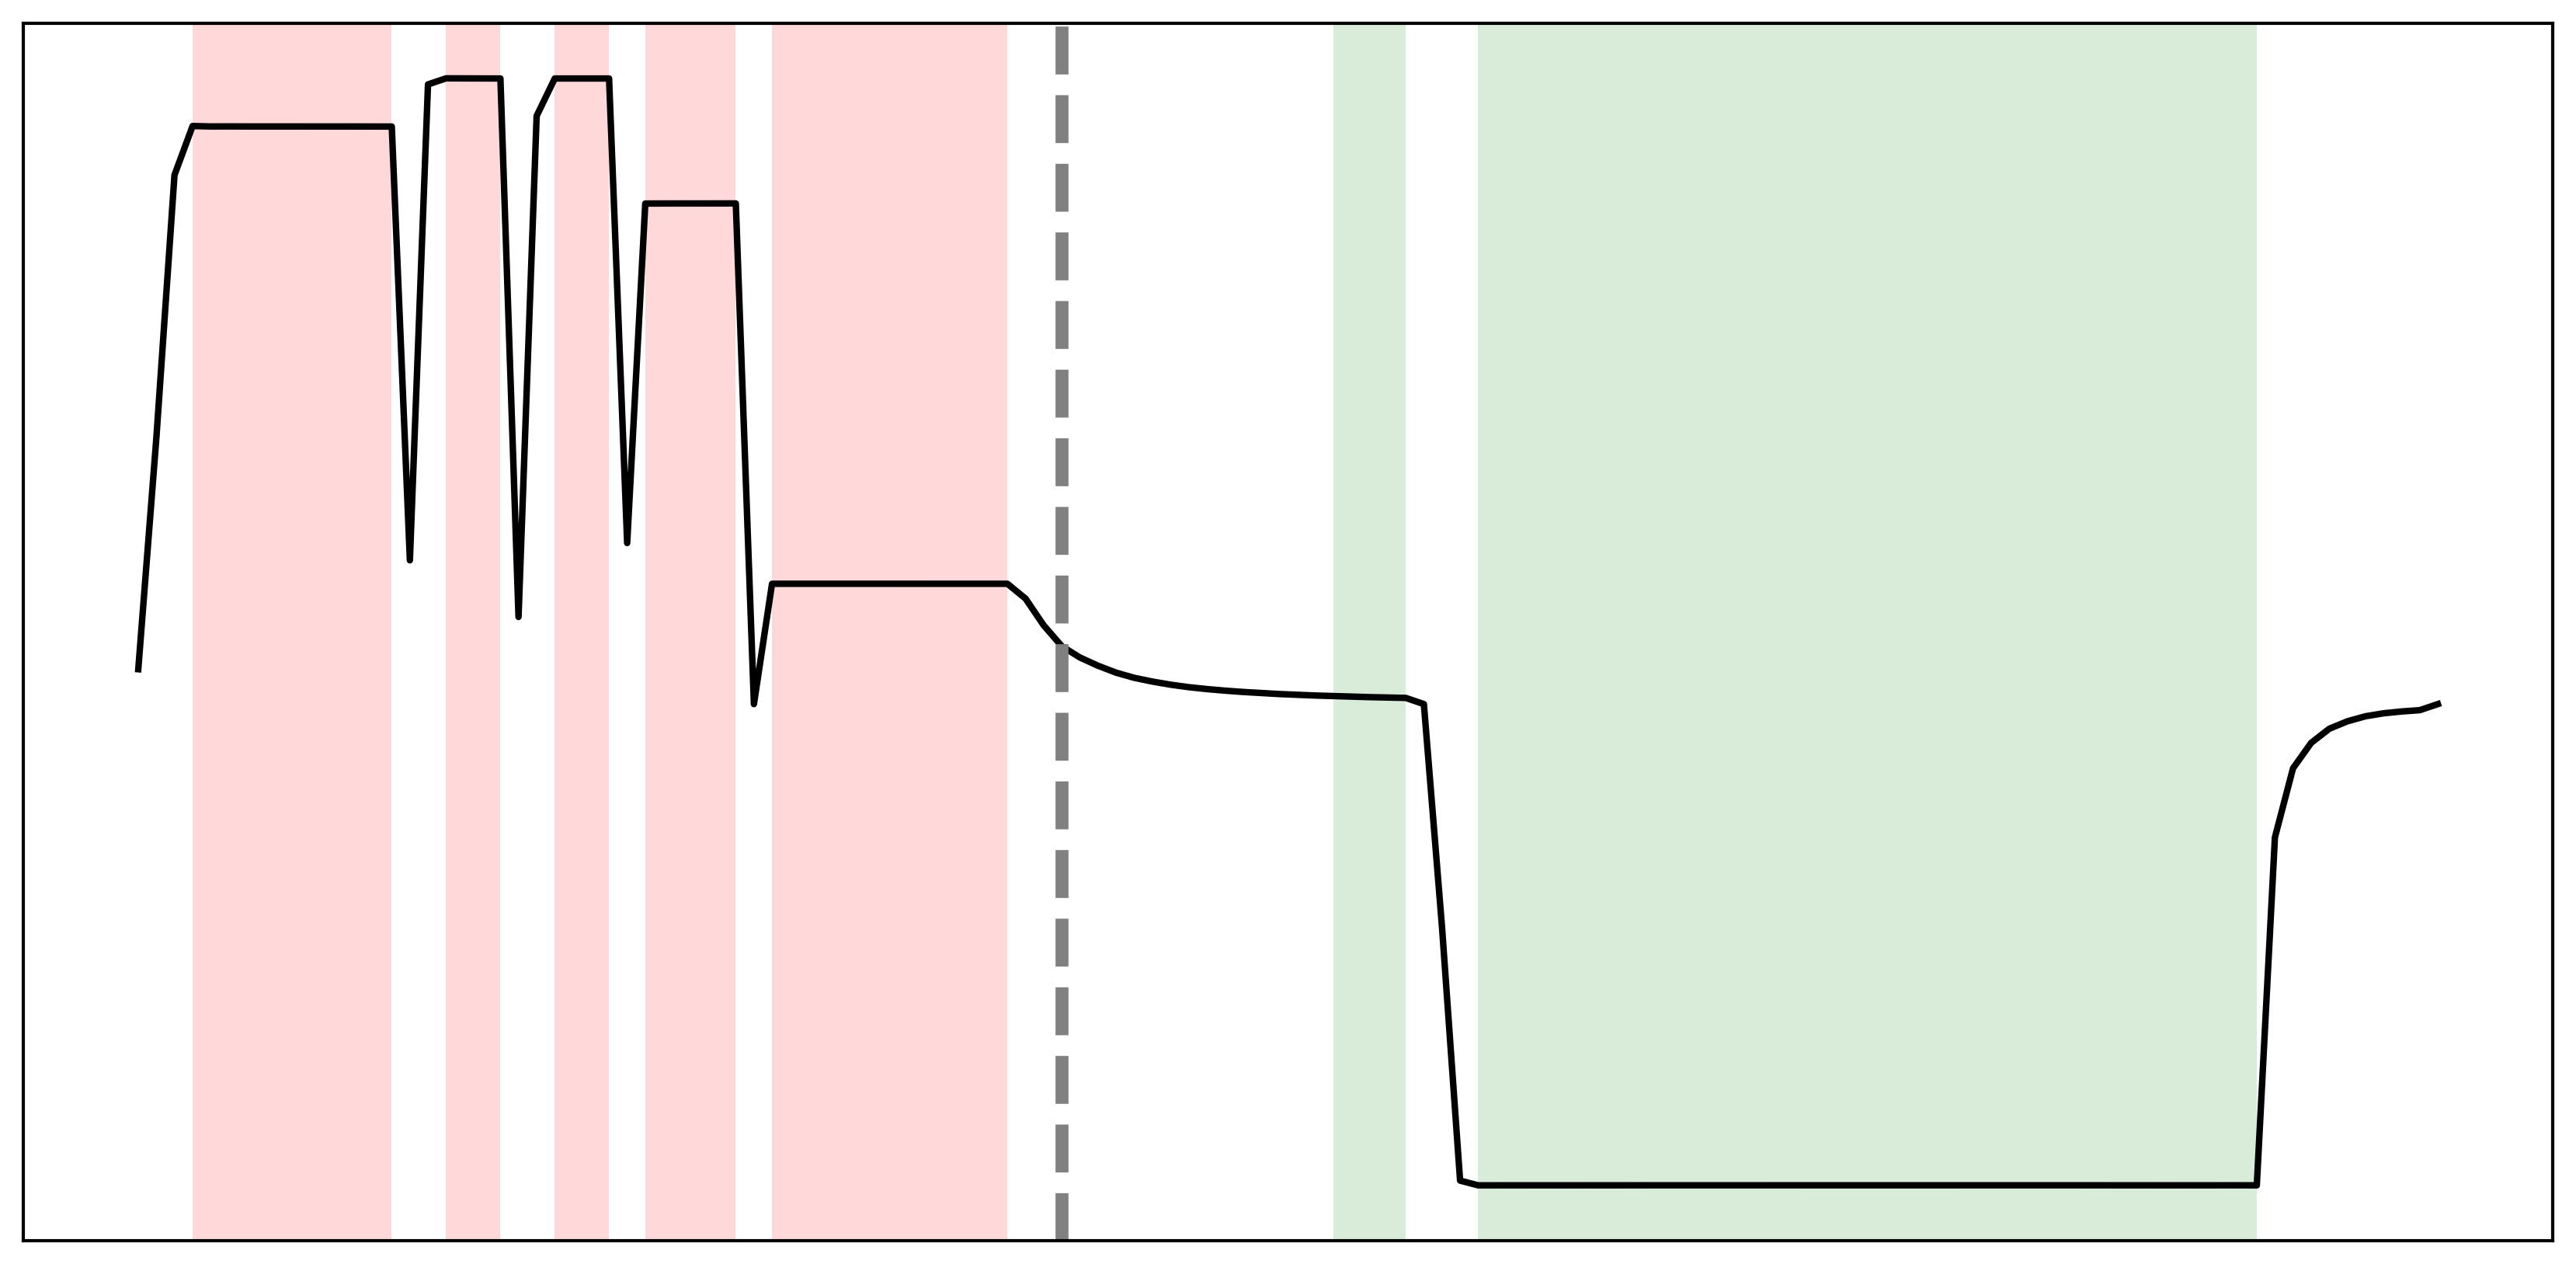

In [11]:
plateaus = find_plateaus(current, tol=1e-3)
print(plateaus)

plt.figure(figsize=(6, 3))
ax = plt.gca()

ax.plot(current)
plt.axvline(x=51, color='grey', lw=2, linestyle='--')

# 高亮平台区（使用更醒目的填充）
charge_plats = []
discharge_plats = []
for start, end in plateaus:
    if end < split_idx:
        charge_plats.append([start, end])
        ax.axvspan(start, end, facecolor='red', alpha=0.15)
    else:
        discharge_plats.append([start, end])
        ax.axvspan(start, end, facecolor='green', alpha=0.15)

# 标注平台统计信息
plat_durations = [e-s+1 for s,e in plateaus]
stats_text = f"平台区总占比: {np.sum(plat_durations) / len(current):.1%}"
print(stats_text)
# 计算充电段平台占比
charge_plat_ratio = sum(e-s+1 for s,e in charge_plats) / len(charge_segment)
print(f"充电段平台区占比: {charge_plat_ratio:.1%}")
discharge_plat_ratio = sum(e-s+1 for s,e in discharge_plats)/len(discharge_segment)
print(f"放电段平台区占比: {discharge_plat_ratio:.1%}")

plt.tight_layout()
ax = plt.gca()
ax.axes.xaxis.set_visible(False)
ax.axes.yaxis.set_visible(False)
plt.savefig('fig1_challenge_subfig11.png')

In [10]:
def save_data_to_csv(data, filename):
    with open(filename, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(['Index', 'Data'])
        writer.writerows([(i+1, value) for i, value in enumerate(data)])

save_data_to_csv(data, './mit_current_signal.csv')